# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## Data Curation Part 2

Today we'll extend our dataset to a greater coverage, and craft it into an excellent dataset for training.  
Data curation can seem less exciting than other things we work on, but it's a crucial part of the LLM engineers' responsibility and an important craft to hone, so that you can build your own commercial solutions with high quality datasets.

The dataset is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023

And the folder with all the product datasets is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/tree/main/raw/meta_categories

## Important Note - read me first please

We are about to craft a massive dataset of 400,000 items covering multiple types of product. In Week 7 we will be using this data to train our own model. It's a pretty big dataset, and depending on the GPU you select, training could take 20+ hours. It will be really good fun, but it could cost a few dollars in compute units.

As an alternative, if you want to keep things quick & low cost, you can work with a smaller dataset focused only on Home Appliances. You'll be able to cover the same learning points; the results will be good -- not quite as good as the full dataset, but still pretty amazing! If you'd prefer to do this, I've set up an alternative jupyter notebook in this folder called `lite.ipynb` that you should use in place of this one.

Also, if you'd prefer, you can shortcut running all this data curation by downloading the pickle files that we save in the last cell. The pickle files are available here: https://drive.google.com/drive/folders/1f_IZGybvs9o0J5sb3xmtTEQB3BXllzrW

In [1]:
# imports

import os
import random
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset, Dataset, DatasetDict
from loaders import ItemLoader
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import numpy as np
import pickle

In [2]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')
os.environ['HF_TOKEN2'] = os.getenv('HF_TOKEN2', 'your-key-if-not-using-env')
os.environ['HF_TOKEN3'] = os.getenv('HF_TOKEN3', 'your-key-if-not-using-env')

In [3]:
# Log in to HuggingFace

#hf_token = os.environ['HF_TOKEN2']
#login(hf_token, add_to_git_credential=True)

In [4]:
# One more import after HF login

from items import Item

In [5]:
%matplotlib inline

## The ItemLoader code

Look in loaders.py - there's some useful code to make life easier for us

In [6]:
# Load in the same dataset as last time

items = ItemLoader("Appliances").load()

Loading dataset Appliances


100%|██████████| 95/95 [00:31<00:00,  3.06it/s]


Completed Appliances with 28,466 datapoints in 0.6 mins


In [7]:
# Look for a familiar item..
print(items[1].prompt)

How much does this cost to the nearest dollar?

Door Pivot Block - Compatible Kenmore KitchenAid Maytag Whirlpool Refrigerator - Replaces - Quick DIY Repair Solution
Pivot Block For Vernicle Mullion Strip On Door - A high-quality exact equivalent for part numbers and Compatibility with major brands - Door Guide is compatible with Whirlpool, Amana, Dacor, Gaggenau, Hardwick, Jenn-Air, Kenmore, KitchenAid, and Maytag. Quick DIY repair - Refrigerator Door Guide Pivot Block Replacement will help if your appliance door doesn't open or close. Wear work gloves to protect your hands during the repair process. Attentive support - If you are uncertain about whether the block fits your refrigerator, we will help. We generally put forth a valiant effort to guarantee you are totally

Price is $17.00


## Now to SCALE UP

Let's look at all datasets of all the items that you might find in a large home retail store - electrical, electronic, office and related, but not clothes / beauty / books.

In [8]:
dataset_names = {
    #"Automotive": "auto",
    #"Electronics": "electro",
    #"Office_Products": "office",
    #"Tools_and_Home_Improvement": "tools",
    #"Cell_Phones_and_Accessories": "cell",
    #"Toys_and_Games": "toys",
    "Appliances": "appliances",
    "Musical_Instruments": "instruments",
}

In [9]:

for key, value in dataset_names.items():
    items = []
    loader = ItemLoader(key)
    items.extend(loader.load())
    item_name = f"items_{value}__.pkl"    
    with open(item_name, "bw") as f:
        pickle.dump(items, f)
        


# Now, time for a coffee break!!
# By the way, I put the biggest datasets first.. it gets faster.

Loading dataset Appliances


100%|██████████| 95/95 [00:27<00:00,  3.39it/s]


Completed Appliances with 28,466 datapoints in 0.5 mins
Loading dataset Musical_Instruments


100%|██████████| 214/214 [00:38<00:00,  5.49it/s]


Completed Musical_Instruments with 66,822 datapoints in 0.7 mins


In [24]:
with open("items_appliances.pkl", "rb") as f:
    tmp = pickle.load(f)
len(tmp)

28466

In [25]:
with open("items_appliances__.pkl", "rb") as f:
    tmp2 = pickle.load(f)
len(tmp2)

28625

In [ ]:
items = []
for value in dataset_names.values():
    item_name = f"items_{value}_.pkl"
    with open(item_name, "rb") as f:
        items.extend(pickle.load(f))

In [ ]:
print(f"A grand total of {len(items):,} items")

A grand total of 2,810,683 items


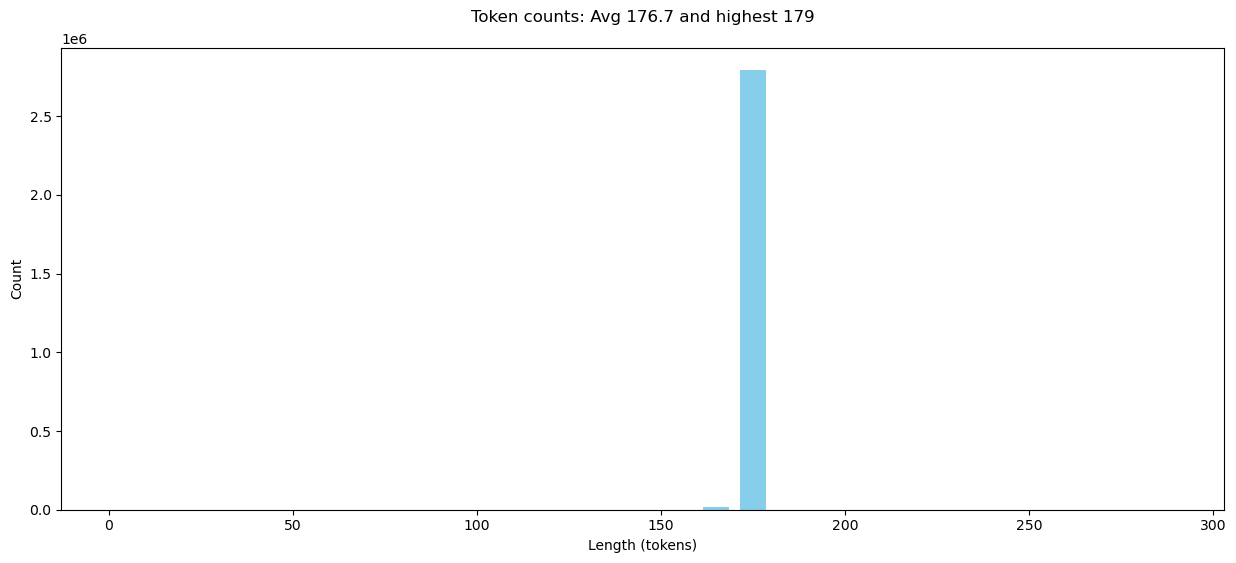

In [7]:
# Plot the distribution of token counts again

tokens = [item.token_count for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Token counts: Avg {sum(tokens)/len(tokens):,.1f} and highest {max(tokens):,}\n")
plt.xlabel('Length (tokens)')
plt.ylabel('Count')
plt.hist(tokens, rwidth=0.7, color="skyblue", bins=range(0, 300, 10))
plt.show()

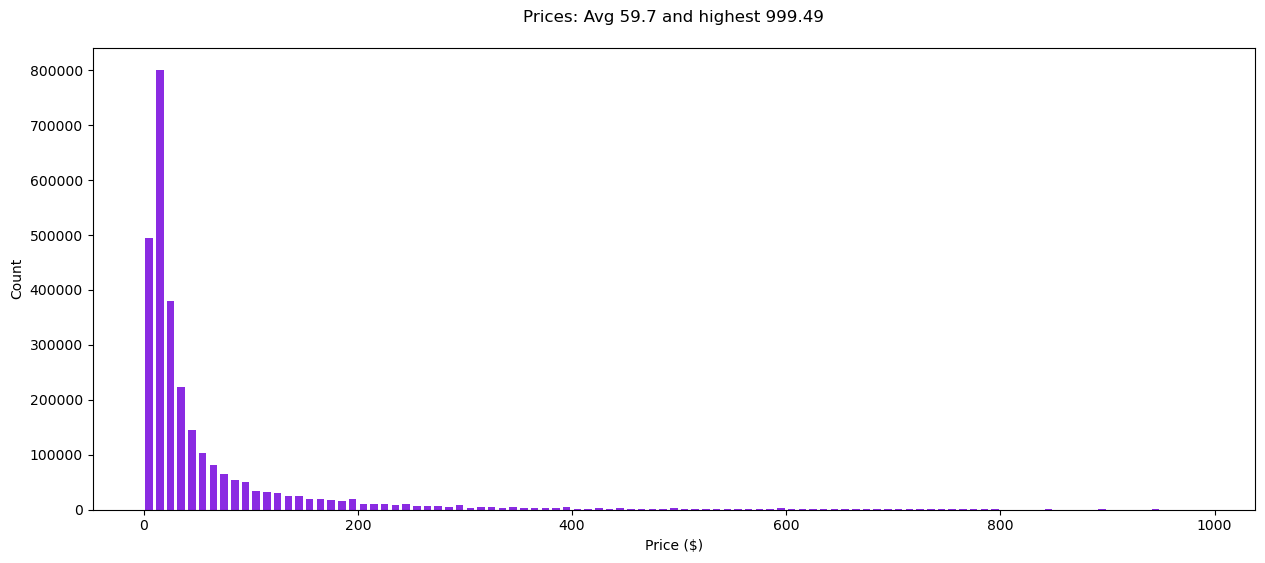

In [8]:
# Plot the distribution of prices

prices = [item.price for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

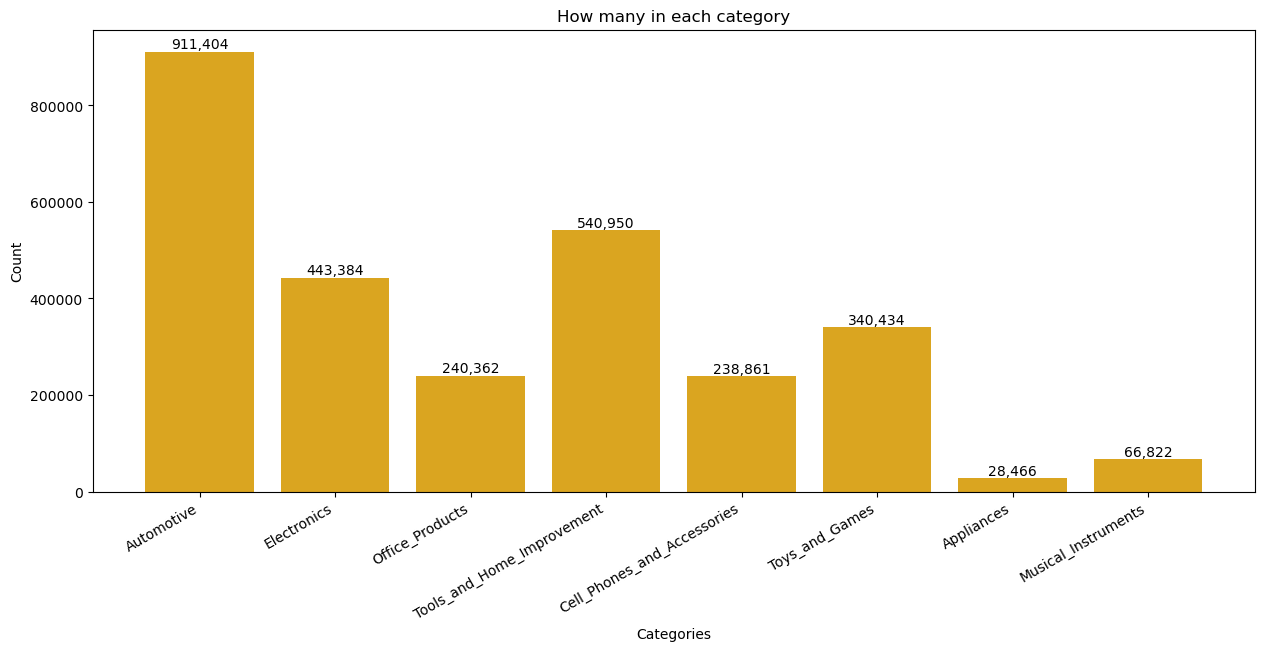

In [9]:
category_counts = Counter()
for item in items:
    category_counts[item.category]+=1

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

# Bar chart by category
plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')

plt.xticks(rotation=30, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

# Display the chart
plt.show()

# Objective

Craft a dataset which is more balanced in terms of prices. Less heavily scewed to cheap items, with an average that's higher than $60. Try to balance out the categories - fewer Automotive items.

In [10]:
# Create a dict with a key of each price from $1 to $999
# And in the value, put a list of items with that price (to nearest round number)

slots = defaultdict(list)
for item in items:
    slots[round(item.price)].append(item)

In [11]:
# Create a dataset called "sample" which tries to more evenly take from the range of prices
# And gives more weight to items from categories other than Automotive
# Set random seed for reproducibility

np.random.seed(42)
random.seed(42)
sample = []
for i in range(1, 1000):
    slot = slots[i]
    if i>=240:
        sample.extend(slot)
    elif len(slot) <= 1200:
        sample.extend(slot)
    else:
        weights = np.array([1 if item.category=='Automotive' else 5 for item in slot])
        weights = weights / np.sum(weights)
        selected_indices = np.random.choice(len(slot), size=1200, replace=False, p=weights)
        selected = [slot[i] for i in selected_indices]
        sample.extend(selected)

print(f"There are {len(sample):,} items in the sample")

There are 408,607 items in the sample


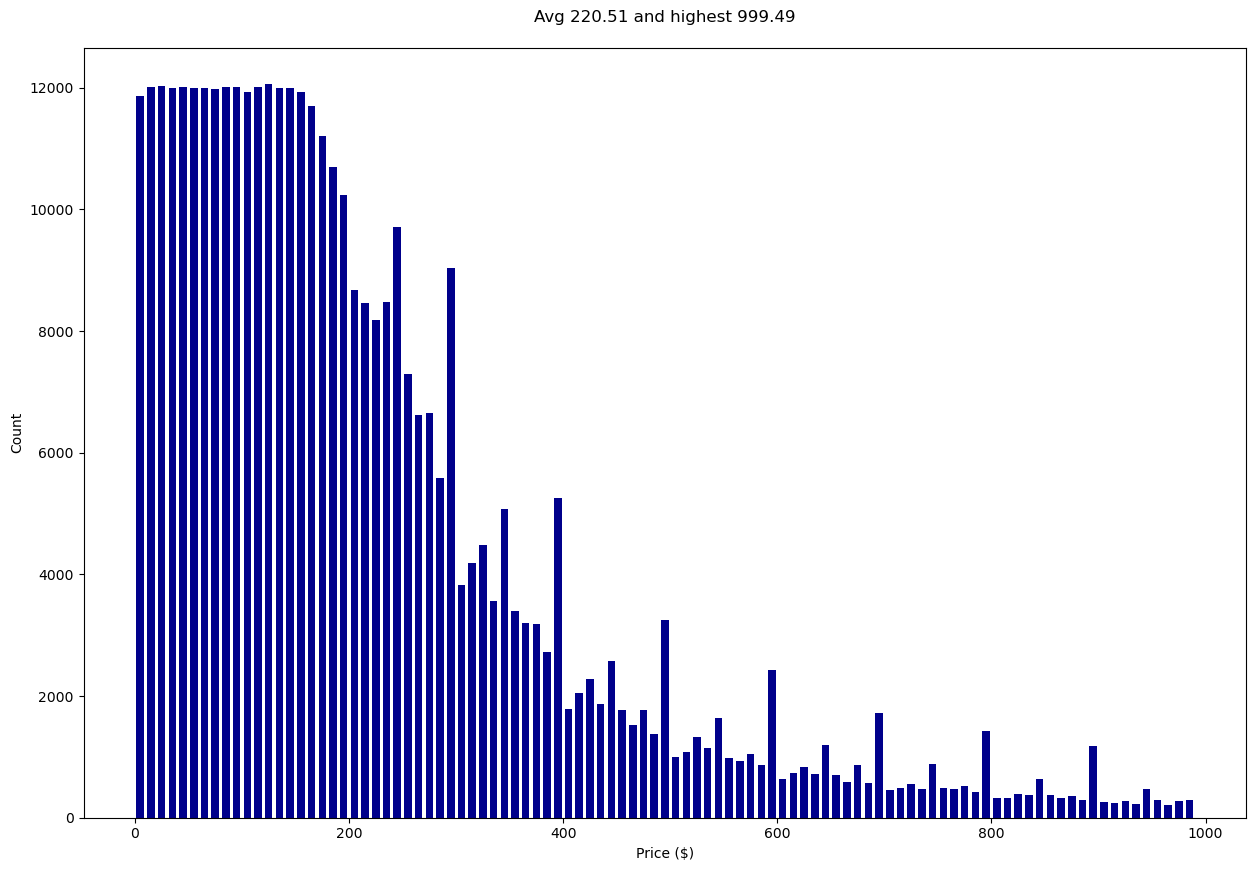

In [12]:
# Plot the distribution of prices in sample

prices = [float(item.price) for item in sample]
plt.figure(figsize=(15, 10))
plt.title(f"Avg {sum(prices)/len(prices):.2f} and highest {max(prices):,.2f}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="darkblue", bins=range(0, 1000, 10))
plt.show()

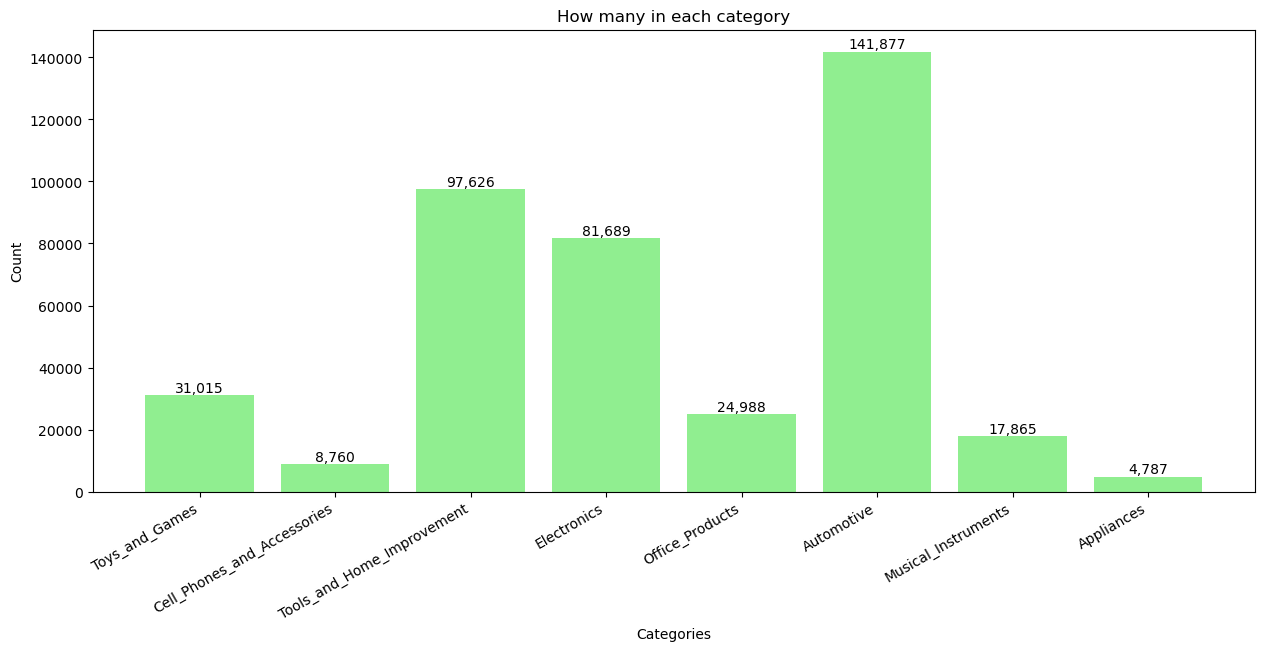

In [13]:
# OK, we did well in terms of raising the average price and having a smooth-ish population of prices
# Let's see the categories

category_counts = Counter()
for item in sample:
    category_counts[item.category]+=1

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

# Create bar chart
plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="lightgreen")

# Customize the chart
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')

plt.xticks(rotation=30, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

# Display the chart
plt.show()

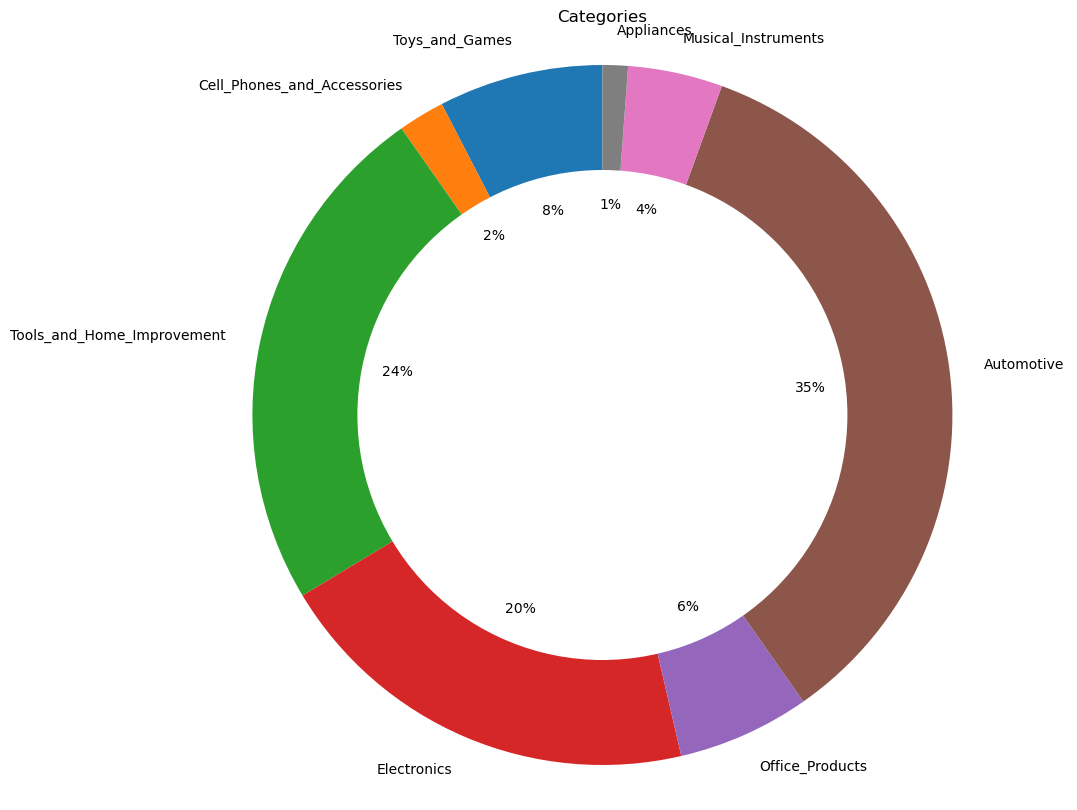

In [14]:
# Automotive still in the lead, but improved somewhat
# For another perspective, let's look at a pie

plt.figure(figsize=(12, 10))
plt.pie(counts, labels=categories, autopct='%1.0f%%', startangle=90)

# Add a circle at the center to create a donut chart (optional)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Categories')

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')  

plt.show()

# Dataset Curated!

We've crafted an excellent dataset.

Let's do some final checks

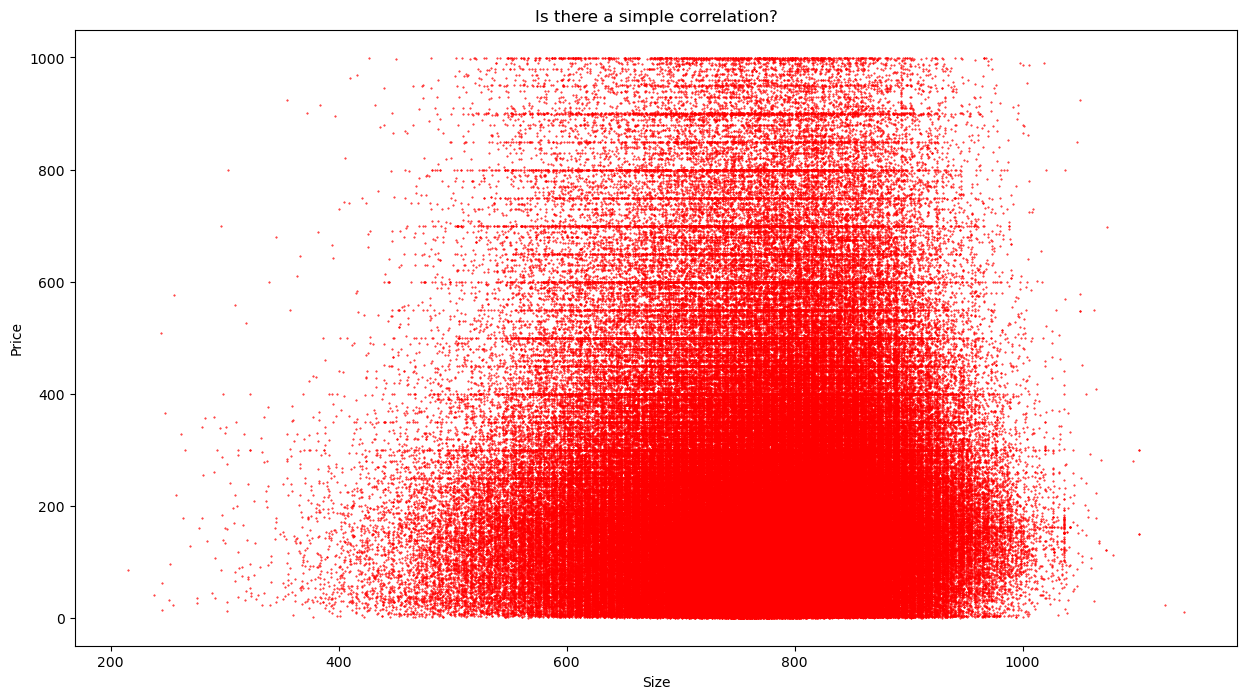

In [15]:
# How does the price vary with the character count of the prompt?

sizes = [len(item.prompt) for item in sample]
prices = [item.price for item in sample]

# Create the scatter plot
plt.figure(figsize=(15, 8))
plt.scatter(sizes, prices, s=0.2, color="red")

# Add labels and title
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Is there a simple correlation?')

# Display the plot
plt.show()

In [19]:
def report(item):
    prompt = item.prompt
    tokens = Item.tokenizer.encode(item.prompt)
    print(prompt)
    print(tokens[-10:])
    print(Item.tokenizer.batch_decode(tokens[-10:]))

In [20]:
report(sample[398000])

How much does this cost to the nearest dollar?

HP Envy X360 2-in-1 Touch Screen Laptop, 15.6 FHD IPS, AMD 6-Core Ryzen 5 5625U (Beat 16GB RAM, 1TB PCIe SSD, USB-C, HDMI, WiFi 6, SD Card Reader, Backlit, SPS HDMI Cable, Win 11
The computer is professionally upgraded and customized. The manufacturer box will be opened by our professional engineers for customizing and testing. Factory defects & blemishes are significantly reduced by our in-depth inspection & testing. We offer a warranty, please feel free to contact us if you need any support from our team. Processor Model AMD Ryzen 5 5625U # of Cores 6 Max Turbo Frequency Up to 4.30 GHz Processor Base

Price is $765.00
[52405, 44477, 5464, 271, 7117, 374, 400, 22240, 13, 410]
[' GHz', ' Processor', ' Base', '\n\n', 'Price', ' is', ' $', '765', '.', '00']


## Observation

An interesting thing about the Llama tokenizer is that every number from 1 to 999 gets mapped to 1 token, much as we saw with gpt-4o. The same is not true of qwen2, gemma and phi3, which all map individual digits to tokens. This does turn out to be a bit useful for our project, although it's not an essential requirement.

# Finally

It's time to break down our data into a training, test and validation dataset.

It's typical to use 5%-10% of your data for testing purposes, but actually we have far more than we need at this point. We'll take 400,000 points for training, and we'll reserve 2,000 for testing, although we won't use all of them.


In [21]:
random.seed(42)
random.shuffle(sample)
train = sample[:400_000]
test = sample[400_000:402_000]
print(f"Divided into a training set of {len(train):,} items and test set of {len(test):,} items")

Divided into a training set of 400,000 items and test set of 2,000 items


In [22]:
print(train[0].prompt)

How much does this cost to the nearest dollar?

CURT 56422 Vehicle-Side Custom 4-Pin Trailer Wiring Harness, Fits Select Volkswagen Tiguan
If your vehicle is not equipped with wiring for towing a trailer, CURT custom wiring is the ideal solution. A custom wiring harness -- also called a T-connector -- is a simple, plug-and-play electrical device that plugs into your automotive electric system and provides a standard, universal trailer wiring connection. This is done using two or more vehicle-specific, OEM-compatible connectors to plug into the taillight assembly, eliminating the need for cutting, splicing and soldering during installation. Custom wiring harnesses are made vehicle-specific, and while they are not available for all vehicles, they do offer one of the fastest, easiest and most secure ways to wire a vehicle for towing. This particular

Price is $67.00


In [23]:
print(test[0].test_prompt())

How much does this cost to the nearest dollar?

NavePoint 4ft Open Frame 19 Inch 22U 4-Post Network Server Relay Rack Rolling with Casters
This 4-post open frame adjustable depth rack by NavePoint is great for organizing your networking equipment. Comes flat-packed and requires some assembly. Made of high-quality SPCC Cold Rolled Steel with a powdered coated finish for durability. The rack comes equipped with casters for easy movement and relocation of equipment. Available in a variety heights. 4-post Open Frame Rack Includes casters (can also floor mount) Supports standard 19 rack mount equipment 44.02 H x 59.2 W x 60 D Rack Depth 9.45 - 15.75 (adjusts in 1.5 increments) Dimensions 61 x 12 x 

Price is $


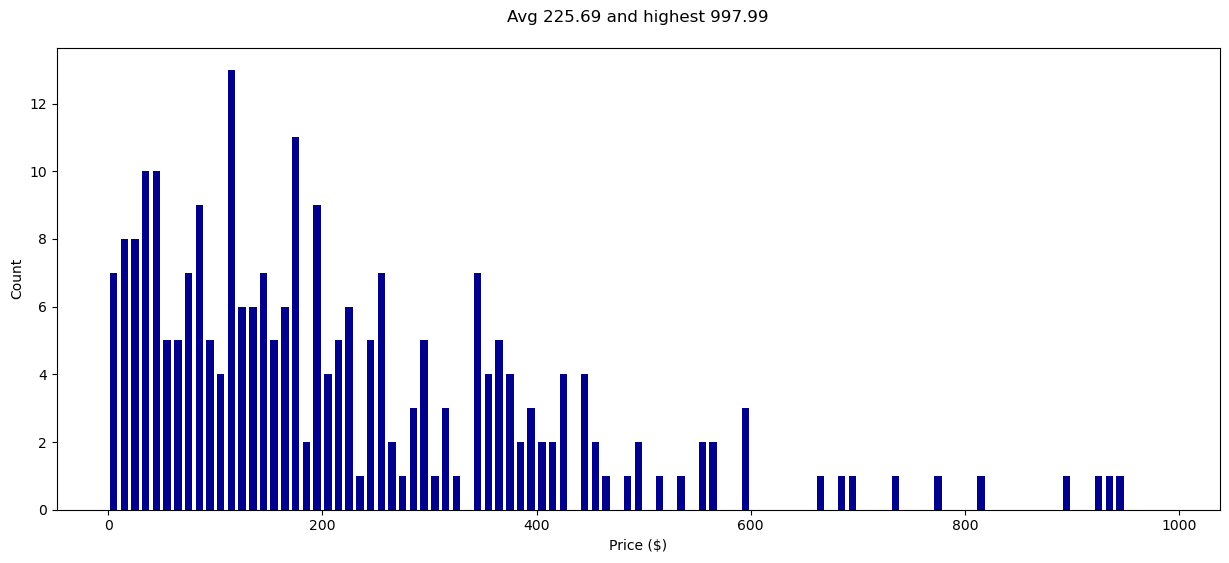

In [24]:
# Plot the distribution of prices in the first 250 test points

prices = [float(item.price) for item in test[:250]]
plt.figure(figsize=(15, 6))
plt.title(f"Avg {sum(prices)/len(prices):.2f} and highest {max(prices):,.2f}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="darkblue", bins=range(0, 1000, 10))
plt.show()

# Finally - upload your brand new dataset

Convert to prompts and upload to HuggingFace hub

In [25]:
train_prompts = [item.prompt for item in train]
train_prices = [item.price for item in train]
test_prompts = [item.test_prompt() for item in test]
test_prices = [item.price for item in test]

In [26]:
# Create a Dataset from the lists

train_dataset = Dataset.from_dict({"text": train_prompts, "price": train_prices})
test_dataset = Dataset.from_dict({"text": test_prompts, "price": test_prices})
dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

In [31]:
!huggingface-cli upload sergio-sanz-rodriguez/pricer-data . --repo-type=dataset

Traceback (most recent call last):
  File "C:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\huggingface_hub\utils\_http.py", line 409, in hf_raise_for_status
    response.raise_for_status()
  File "C:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\requests\models.py", line 1024, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 403 Client Error: Forbidden for url: https://huggingface.co/api/repos/create

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\ssre_\.conda\envs\.venv_llms\Scripts\huggingface-cli.exe\__main__.py", line 7, in <module>
  File "C:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\huggingface_hub\commands\huggingface_cli.py", line 59, in main
    service.run()
  File "C:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\

In [ ]:
#os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')
#hf_token = os.environ['HF_TOKEN3']
#login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [ ]:
# Uncomment these lines if you're ready to push to the hub, and replace my name with your HF username

# HF_USER = "ed-donner" 
# DATASET_NAME = f"{HF_USER}/pricer-data"
# dataset.push_to_hub(DATASET_NAME, private=True)

#HF_USER = "sergio-sanz-rodriguez" 
#DATASET_NAME = f"{HF_USER}/pricer-data"
#dataset.push_to_hub(DATASET_NAME, private=True)


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/400 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

README.md:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ssre_\.cache\huggingface\hub\datasets--sergio-sanz-rodriguez--pricer-data. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


CommitInfo(commit_url='https://huggingface.co/datasets/sergio-sanz-rodriguez/pricer-data/commit/1b3fb9b2ca88eea7ec9c923aba13ee30f81cf455', commit_message='Upload dataset', commit_description='', oid='1b3fb9b2ca88eea7ec9c923aba13ee30f81cf455', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/sergio-sanz-rodriguez/pricer-data', endpoint='https://huggingface.co', repo_type='dataset', repo_id='sergio-sanz-rodriguez/pricer-data'), pr_revision=None, pr_num=None)

In [ ]:
# One more thing!
# Let's pickle the training and test dataset so we don't have to execute all this code next time!

with open('train.pkl', 'wb') as file:
    pickle.dump(train, file)

with open('test.pkl', 'wb') as file:
    pickle.dump(test, file)

## Todos for you:

- Investigate the dataset more!
- Confirm that the tokenizer tokenizes all 3 digit prices into 1 token